In [153]:
import pandas as pd 
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [154]:
retail_data = 'C:/Users/Killi/OneDrive/Programming For Data Analytics/Jupyter/Datasets/retail_store_sales.csv'
data = pd.read_csv(retail_data)

This section begins by loading the Python libraries required for data cleaning. pandas provides the DataFrame structure and the majority of tools used to manipulate the dataset, numpy is used for handling numerical operations and defining special values such as NaN. Once these libraries are imported the raw retail dataset is read from its CSV file into a DataFrame named data. 

In [155]:
data = data.rename(columns={
    "Transaction ID": "transaction_id",
    "Customer ID": "customer_id",
    "Category": "category",
    "Item": "item",
    "Price Per Unit": "price_per_unit",
    "Quantity": "quantity",
    "Total Spent": "total_spent",
    "Payment Method": "payment_method",
    "Location": "location",
    "Transaction Date": "transaction_date",
    "Discount Applied": "discount_applied",
    "Day Of Week": "day_of_week",
    "Is Weekend": "is_weekend"
})

# Show new column names
print("Renamed columns:\n")
print(data.columns)

Renamed columns:

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'discount_applied'],
      dtype='object')


# Renaming Columns for Consistency and Clarity

To improve readability all column names are renamed using a consistent format. This involves converting names
to lowercase and replacing spaces with underscores.

Consistent naming makes the code easier to write and understand. For example:
- Total Spent -> total_spent
- Payment Method -> payment_method

Many libraries (e.g., statsmodels, seaborn) interact more cleanly with underscore-based names this:
- avoid conflicts with Python syntax
- reduce the need for quoting column names in formulas (Q("Column Name"))
- make modelling formulas simpler.
  
Lowercase naming eliminates inconsistencies such as Category vs. category preventing accidental mismatches.

 
Regression formulas and visualisations all benefit from clear predictable column names.


In [156]:
# Preview first rows
print(data.head())

# Structure of the dataset
print(data.info())

# Summary statistics (numeric only)
print(data.describe())

# Count missing values per column
print(data.isna().sum())

# Data types
print(data.dtypes)


  transaction_id customer_id       category          item  price_per_unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   quantity  total_spent  payment_method location transaction_date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  discount_applied  
0             True  
1             True  
2            False  
3              NaN  
4          

This block performs an initial inspection of the raw dataset. The head() function displays the first few rows giving a quick summary of the column structure and the type of information recorded. info() then gives an overview of the dataset including the number of rows, columns, data types and counts of non-null entries. This reveals which columns contain missing values and how the data types have been interpreted by pandas. describe() summarises the numerical fields and turns them into their ranges, averages and overall distribution. isna().sum() counts the missing values in each column. 

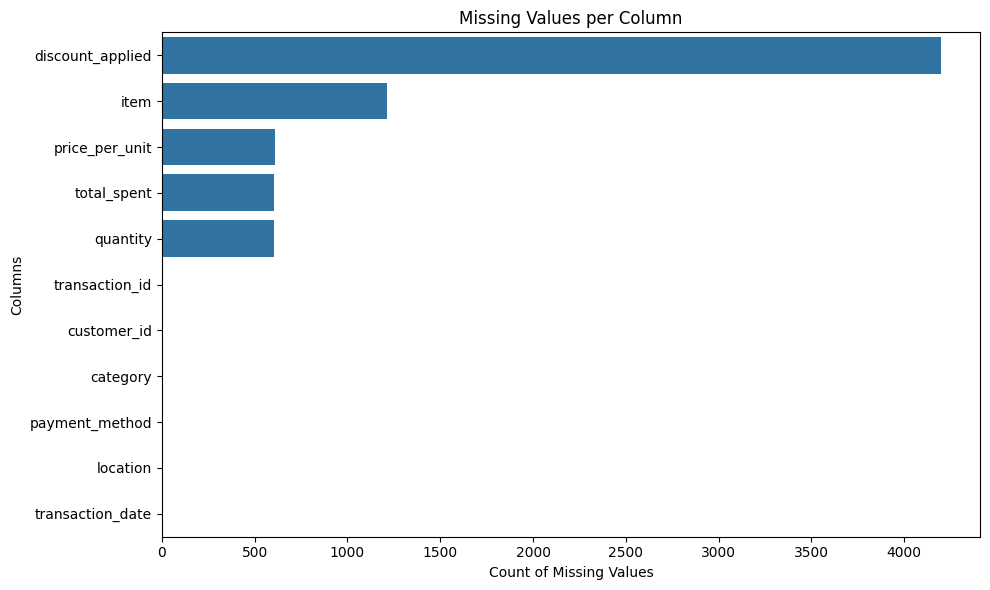

In [157]:
# Bar chart of missing values
missing_counts = data.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=missing_counts.values, y=missing_counts.index)
plt.title("Missing Values per Column")
plt.xlabel("Count of Missing Values")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()

# Interpretation of Missing Values per Column

The bar chart shows the number of missing values in each column of the dataset. The pattern of missingness is uneven across variables:

- Discount Applied has the highest number of missing values (over 4,000).  
This shows that discount information is inconsistently recorded or optional at the point of sale. Because this variable has alot missingness and is not essential for the analyses it may need treatment (e.g., filling with “No Discount”) or removal.

- Item also contains a significant number of missing entries (approximately 1,200).  
Since item names are descriptive these missing values can be replaced with a placeholder such as "Missing" without affecting numerical modelling.

- Price Per Unit, Quantity and Total Spent each contain several hundred missing values.  These are numerical variables so missing entries must be treated carefully. 

- Other columns such as Transaction ID, Customer ID, Category, Payment Method, Location and Transaction Date show no missingness indicating consistent data collection for key categorical identifiers.


In [158]:
# Replace missing item names with "Missing"
data["item"] = data["item"].fillna("Missing")

# Replace missing discount information with "No Discount"
data["discount_applied"] = data["discount_applied"].fillna("No Discount")


# Check that all missing values are now handled
print("Missing values after filling Item and Discount Applied:\n")
print(data.isna().sum())

Missing values after filling Item and Discount Applied:

transaction_id        0
customer_id           0
category              0
item                  0
price_per_unit      609
quantity            604
total_spent         604
payment_method        0
location              0
transaction_date      0
discount_applied      0
dtype: int64


# Missing Value Handling for Item and Discount Applied

Missing values in two categorical variables Item and Discount Applied are fixed using appropriate imputation methods.

Missing entries in the Item column are replaced with the label "Missing".  

- Item is a descriptive categorical variable rather than a numerical predictor. The absence of an item name does not affect analyses involving spending behaviour.
- Creating a "Missing" category preserves all transactions and prevents loss of data.

Missing values in Discount Applied are replaced with "No Discount".  

- Many retail systems leave discount fields blank unless a discount was applied. The dataset shows a very high number of missing entries for this variable so removing rows would cause unnecessary data loss.
- This replacement helps keep the dataset complete.

After imputing both columns the code prints a summary of missing values across all variables.  

This confirms that:
- Missingness has been fixed for these two categorical fields.
- Remaining missing values are numeric which will be handled later during outlier detection and imputation.

This step ensures that categorical variables are complete and ready for further analysis without impacting the quality of numerical modelling.


In [159]:
nonsense_values = ["?", "error", "missing", "NaN", "None","N/A", "nan", " ", "???", "bad"]

print("Columns that contain any nonsense values:\n")
print(data.isin(nonsense_values).any())
print("\n")

print("Number of nonsense values in each column:\n")
print(data.isin(nonsense_values).sum())
print("\n")


# Replace nonsense values with proper missing values (NaN)
data = data.replace(nonsense_values, np.nan)

missing_after_nonsense = data.isnull().sum()
print("Missing values in each column AFTER replacing nonsense values:\n")
print(missing_after_nonsense)
print("\n")

# Focus on main numeric transaction columns
numeric_cols = ["price_per_unit", "quantity", "total_spent"]

numeric_data = data[numeric_cols].apply(pd.to_numeric,errors="coerce")

print("Missing values in numeric columns after coercion:\n")
print(numeric_data.isna().sum())
print("\n")

# Detect outliers with IQR method
Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Boolean mask for outliers
outlier_mask = (numeric_data < lower_bound) | (numeric_data > upper_bound)

# Count outliers per column
outlier_counts = outlier_mask.sum()
outlier_summary = pd.DataFrame(outlier_counts,columns=["Number_of_Outliers"])

print("Outlier counts in each numeric column:\n")
print(outlier_summary)
print("\n")

# Handle missing values & outliers
# Replace outliers with NaN
numeric_cleaned = numeric_data.mask(outlier_mask)

# Fill missing numeric values (original NaN + outliers) with column means
numeric_cleaned = numeric_cleaned.fillna(numeric_cleaned.mean(numeric_only=True))

# Put cleaned numeric columns back into main dataset
data[numeric_cols] = numeric_cleaned

# Check that values are now within the IQR bounds
print("Summary statistics for cleaned numeric columns:\n")
print(data[numeric_cols].describe())
print("\n")

# Check remaining missing values after cleaning
missing_final = data.isnull().sum()
print("Missing values in each column AFTER handling missing values and outliers:\n")
print(missing_final)


Columns that contain any nonsense values:

transaction_id      False
customer_id         False
category            False
item                False
price_per_unit      False
quantity            False
total_spent         False
payment_method      False
location            False
transaction_date    False
discount_applied    False
dtype: bool


Number of nonsense values in each column:

transaction_id      0
customer_id         0
category            0
item                0
price_per_unit      0
quantity            0
total_spent         0
payment_method      0
location            0
transaction_date    0
discount_applied    0
dtype: int64


Missing values in each column AFTER replacing nonsense values:

transaction_id        0
customer_id           0
category              0
item                  0
price_per_unit      609
quantity            604
total_spent         604
payment_method        0
location              0
transaction_date      0
discount_applied      0
dtype: int64


Missing values

# Handling Nonsense Values, Missing Numeric Values and Outlier Treatment

This section is the most important stage of data cleaning: ensuring that all numeric variables are valid, consistent and free from extreme values that could affect statistical modelling.

A set of invalid placeholder entries (e.g., "?", "error","N/A", "None") is defined and searched for across all columns. These values represent incomplete data and are converted to proper NaN values so they can be handled.

The main numeric fields Price Per Unit, Quantity and Total Spent are converted to numeric types using errors="coerce". Any remaining invalid values become NaN ensuring
clean numerical structure for outlier detection.

A count of missing values in these numeric columns verifies how many values need imputation.

Outliers can affect statistical models, increase variance and weaken relationships.

To detect them the Interquartile Range (IQR) method is applied:

- Q1: 25th percentile  
- Q3: 75th percentile  
- IQR = Q3 − Q1  
- Outliers are values below Q1 − 1.5·IQR or above Q3 + 1.5·IQR  

A boolean mask identifies all outliers and a summary table shows how many appear in each numeric column. This shows extreme values in the dataset.

Instead of deleting observations outliers are replaced with NaN using .mask().  
This keeps row count while preventing extreme values from influencing models later.

All numeric missing values that were originally missing, invalid or outliers are then imputed using the mean of each column. 

This approach:
- preserves the overall central tendency  
- avoids bias from dropping rows  
- ensures the dataset remains fully usable for regression and statistical tests  

# Validating the Cleaned Numeric Columns
describe() is used to confirm:

- that the cleaned columns are now within useable ranges  
- that extreme outliers have been removed  
- that mean and distributional shape remain reasonable  

A final missing-value check verifies that all numeric fields are now complete.


Earliest transaction date: 2022-01-01 00:00:00
Latest transaction date: 2025-01-18 00:00:00

First 5 transaction dates after sorting:
0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
Name: transaction_date, dtype: datetime64[ns]

Last 5 transaction dates after sorting:
12570   2025-01-18
12571   2025-01-18
12572   2025-01-18
12573   2025-01-18
12574   2025-01-18
Name: transaction_date, dtype: datetime64[ns]


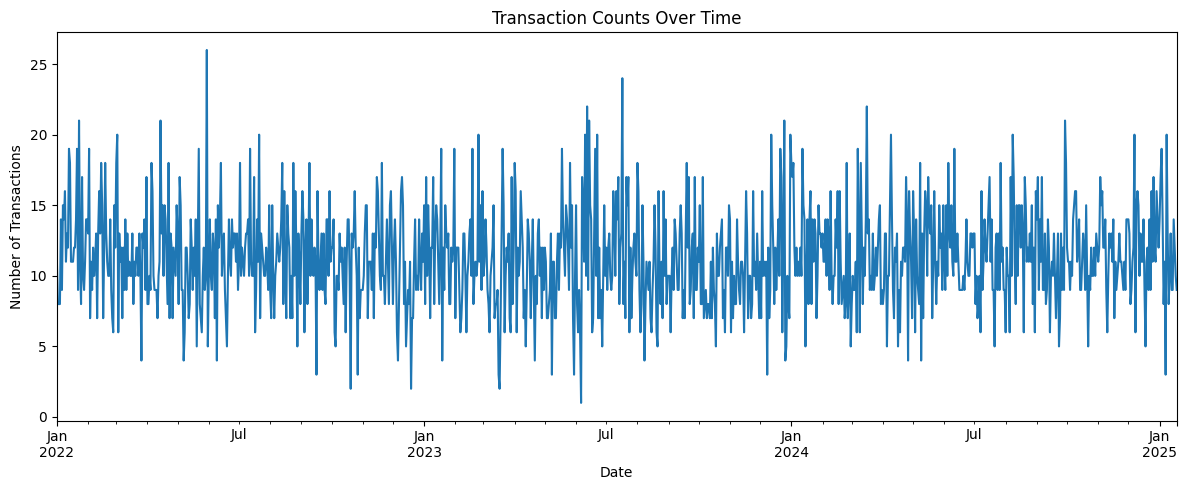

In [160]:
# Convert transaction_date to datetime
data["transaction_date"] = pd.to_datetime(data["transaction_date"])

# Quick check of the date range
print("Earliest transaction date:", data["transaction_date"].min())
print("Latest transaction date:", data["transaction_date"].max())

# Sort the dataset by date
data = data.sort_values(by="transaction_date")

# Reset the index after sorting
data = data.reset_index(drop=True)

# Check that ordering looks correct
print("\nFirst 5 transaction dates after sorting:")
print(data["transaction_date"].head())

print("\nLast 5 transaction dates after sorting:")
print(data["transaction_date"].tail())

# Plot transaction frequency over time
plt.figure(figsize=(12,5))
data["transaction_date"].value_counts().sort_index().plot()
plt.title("Transaction Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# Converting and Sorting Transaction Dates

The Transaction Date column is converted to a proper datetime format to ensure that Python can correctly interpret and sort dates. This is needed for any time-based analysis such as identifying trends, seasonality or changes in transaction
behaviour over time.

After conversion the earliest and latest dates are inspected to confirm that the dataset covers is correct. Sorting the data chronologically ensures that transactions appear in the correct order which is important for:
 
- trend analysis  
- consistency checks  
- ensuring that no rows have incorrect formatting or import issues  

Resetting the index after sorting keeps a clean row structure.

Printing the first and last few transaction dates provides a manual verification step confirming that the dataset is now properly ordered from the earliest to the latest recorded
transaction.


This plot shows how the number of transactions varies over time. A smooth and continuous time series confirms that the Transaction Date field was sorted correctly. Sudden drops
or spikes could indicate data entry anomalies or missing days.


In [161]:
# Create day of the week and weekend indicator

# Extract the day name (Monday, Tuesday, etc.)
data["day_of_week"] = data["transaction_date"].dt.day_name()

# Create a weekend flag (True/False)
data["is_weekend"] = data["day_of_week"].isin(["Saturday", "Sunday"])

# Quick checks
print("Unique day names:", data["day_of_week"].unique())
print("\nCount of weekend vs weekday:")
print(data["is_weekend"].value_counts())


Unique day names: ['Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday']

Count of weekend vs weekday:
is_weekend
False    8977
True     3598
Name: count, dtype: int64


# Creating Day-of-Week and Weekend Indicators

To improve the dataset with time-based features the weekday name is extracted from the Transaction Date column using .dt.day_name(). This creates a new categorical variable
Day of Week which identifies the specific day on which each transaction occurred.

A binary indicator Is Weekend is created to select between weekday and weekend transactions. This flag is used because consumer spending behaviour often differs on weekends and it allows later analyses (such as t-tests, ANOVA and regression models) to examine whether total spending varies between the two periods. 

The printed outputs have two purposes:
- Listing the unique day names verifies that all seven days were parsed correctly.
- Counting the number of True (weekend) versus False (weekday) to confirm that the dataset contains a balanced distribution of transactions across the week.


In [162]:
# Standardise categorical text fields

# Strip whitespace and apply Title Case
data["category"] = data["category"].str.strip().str.title()
data["payment_method"] = data["payment_method"].str.strip().str.title()
data["location"] = data["location"].str.strip().str.title()
data["discount_applied"] = data["discount_applied"].str.strip().str.title()

# Replace inconsistent category labels

data["payment_method"] = data["payment_method"].replace({
    "Cc": "Credit Card",
    "Credit": "Credit Card",
    "Creditcard": "Credit Card",
    "Debit": "Debit Card",
    "Cash Payment": "Cash",
    "Digital": "Digital Wallet",
    "Apple Pay": "Digital Wallet",
    "Google Pay": "Digital Wallet"
})

data["category"] = data["category"].replace({
    "Elec": "Electronics",
    "Electronic": "Electronics",
    "Groceries": "Grocery",
    "Grocery Items": "Grocery",
    "Clth": "Clothing",
    "Clothes": "Clothing"
})

# Checks of cleaned categories
print("Unique Categories:", data["category"].unique())
print("\nUnique Payment Methods:", data["payment_method"].unique())
print("\nUnique Locations:", data["location"].unique())
print("\nUnique Discount Applied:", data["discount_applied"].unique())


Unique Categories: ['Milk Products' 'Computers And Electric Accessories' 'Food' 'Beverages'
 'Butchers' 'Electric Household Essentials' 'Furniture' 'Patisserie']

Unique Payment Methods: ['Digital Wallet' 'Credit Card' 'Cash']

Unique Locations: ['In-Store' 'Online']

Unique Discount Applied: [nan 'No Discount']


# Cleaning and Standardising Categorical Variables

Many categorical variables in the dataset contain inconsistencies due to differences in
capitalisation, spelling variations, trailing spaces or multiple labels referring to the same
category. These inconsistencies can cause problems in analysis because Python treats each
unique string as a separate category even when they represent the same concept.

Whitespace is stripped from each categorical field and the text is converted to Title Case.
This ensures a consistent and readable format across:
- Category
- Payment Method
- Location
- Discount Applied

Several categories contained alternative spellings or shortened versions. These are replaced
with standardised labels.

Fially unique values in each categorical column after cleaning are listed.
This confirms:
- all categories are standardised
- no new categories were created
- and all duplicates or inconsistent labels were successfully merged.


In [163]:
# Check for duplicate rows
print("Number of duplicate rows BEFORE removal:")
print(data.duplicated().sum())

# Remove duplicate rows
data = data.drop_duplicates()

print("\nNumber of duplicate rows AFTER removal:")
print(data.duplicated().sum())
# Reset index for a clean dataset
data = data.reset_index(drop=True)

# Show updated dataset dimensions
print("\nFinal dataset shape (rows, columns):")
print(data.shape)

# Preview after cleaning
print("\nPreview of cleaned data:")
print(data.head())


Number of duplicate rows BEFORE removal:
0

Number of duplicate rows AFTER removal:
0

Final dataset shape (rows, columns):
(12575, 13)

Preview of cleaned data:
  transaction_id customer_id                            category  \
0    TXN_2070726     CUST_22                       Milk Products   
1    TXN_1519499     CUST_15  Computers And Electric Accessories   
2    TXN_9364474     CUST_19                                Food   
3    TXN_6950467     CUST_01  Computers And Electric Accessories   
4    TXN_6329331     CUST_24                           Beverages   

           item  price_per_unit  quantity  total_spent  payment_method  \
0   Item_6_MILK            12.5       5.0         62.5  Digital Wallet   
1    Item_6_CEA            12.5       6.0         75.0     Credit Card   
2  Item_22_FOOD            36.5       3.0        109.5            Cash   
3    Item_6_CEA            12.5       6.0         75.0  Digital Wallet   
4    Item_8_BEV            15.5       5.0         77.5     

# Detecting and Removing Duplicate Rows

Duplicate rows can occur during data collection, merging or exporting. They artificially increase transaction counts and can bias statistical analyses.

The initial check using data.duplicated().sum() finds how many rows in the dataset are exact duplicates of previous rows. 

data.drop_duplicates() is applied to eliminate any repeated rows while keeping the first one. This keeps the structure of the dataset and ensures each transaction is counted only once.

After duplicates are removed the index is reset so that row numbering is clean continuous in the updated dataset.

The updated dataset shape confirms:
- No duplicate rows remain
- The dataset keeps all necessary variables
- And the structure is clean and ready for modelling.


In [164]:
# Remove non-positive values
print("Shape BEFORE removing non-positive values:", data.shape)

data = data[data["price_per_unit"] > 0]
data = data[data["quantity"] > 0]
data = data[data["total_spent"] > 0]

print("Shape AFTER removing non-positive values:", data.shape)

# Quick check of minimum values
print("\nMinimum values after cleaning:")
print(data[["price_per_unit", "quantity", "total_spent"]].min())


Shape BEFORE removing non-positive values: (12575, 13)
Shape AFTER removing non-positive values: (12575, 13)

Minimum values after cleaning:
price_per_unit    5.0
quantity          1.0
total_spent       5.0
dtype: float64


# Removing Non-Positive Values from Numeric Columns

In retail transaction data, values such as Price Per Unit, Quantity and Total Spent should always be strictly positive. Negative or zero values indicate errors in data entry or placeholder values that do not represent real transactions.

Rows with:
- Price Per Unit ≤ 0  
- Quantity ≤ 0  
- Total Spent ≤ 0  

Were removed entirely. These observations cannot be imputed because a transaction cannot involve a free or negative amount of goods.

Removing such observations keeps the integrity of the dataset and ensures that all remaining values represent valid retail purchases.

The updated dataset shape confirms how many invalid rows were removed.  A final check of minimum values verifies that all remaining numeric entries are positive.

 

In [165]:
# Recalculate total
data["recalc_total"] = data["price_per_unit"] * data["quantity"]

# Count how many rows were inconsistent before fixing
inconsistencies = (data["recalc_total"] != data["total_spent"]).sum()
print("Number of inconsistent totals before fixing:", inconsistencies)

# Overwrite total_spent with the recalculated values
data["total_spent"] = data["recalc_total"]
# Drop the helper column
data = data.drop(columns=["recalc_total"])

# Check of summary stats
print("\nSummary of cleaned total_spent:")
print(data["total_spent"].describe())














Number of inconsistent totals before fixing: 1269

Summary of cleaned total_spent:
count    12575.000000
mean       129.689385
std         92.165610
min          5.000000
25%         52.595606
50%        110.727592
75%        190.000000
max        410.000000
Name: total_spent, dtype: float64


# Recalculating and Validating Total Spent

In retail datasets the Total Spent value should always equal the product of Price Per Unit and Quantity. Data entry errors, rounding issues or inconsistent export formats can
lead to mismatches. 

A new column recalc_total is computed using:

Total = Price Per Unit × Quantity

This represents the correct transaction value based on unit price and quantity purchased.

The code checks how many rows contain differences between the existing total_spent value and the recalculated total. 

The original total_spent column is then overwritten with the recalculated values ensuring that all totals are consistent.

The temporary recalc_total column is removed.

Summary statistics for the cleaned total_spent variable confirm that the values are numerically ok and fall within expected transaction ranges.



In [166]:
data = data.drop(columns=["discount_applied"])
print(data.columns)
print(data.isna().sum())

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'day_of_week', 'is_weekend'],
      dtype='object')


transaction_id      0
customer_id         0
category            0
item                0
price_per_unit      0
quantity            0
total_spent         0
payment_method      0
location            0
transaction_date    0
day_of_week         0
is_weekend          0
dtype: int64


# Removing the Discount Applied Column
Due to a large number of missing values and the limited usefulness of the discount_applied column this section removes it using .drop(). This simplifies the dataset and avoids adding assumptions into thousands of rows.

In [167]:
# Select all object (string) columns
obj_cols = data.select_dtypes(include="object").columns

print(obj_cols)

# Strip leading/trailing spaces from each object column
data[obj_cols] = data[obj_cols].apply(lambda col: col.str.strip())

# check one or two columns
print("\nUnique categories after stripping spaces:")
print(data["category"].unique())

print("\nUnique payment methods after stripping spaces:")
print(data["payment_method"].unique())

Index(['transaction_id', 'customer_id', 'category', 'item', 'payment_method',
       'location', 'day_of_week'],
      dtype='object')

Unique categories after stripping spaces:
['Milk Products' 'Computers And Electric Accessories' 'Food' 'Beverages'
 'Butchers' 'Electric Household Essentials' 'Furniture' 'Patisserie']

Unique payment methods after stripping spaces:
['Digital Wallet' 'Credit Card' 'Cash']


# Stripping Whitespace From Categorical Columns

This step helps fix categorical variables. Even after standardising labels and fixing inconsistent spellings string-based columns can still contain hidden leading or trailing spaces. 

These spaces cause problems because:

- "Cash" and "Cash " would be treated as different categories  
- Grouping, merging and modelling can fail silently to inconsistencies  
- Category counts and statistical summaries become misleading.

All columns with object dtype like string-based categorical variables are identified using select_dtypes(include="object"). This ensures the cleaning step is applied consistently to all fields.

Whitespace is removed from both ends of each string using.str.strip().  
Applying this to all object columns prevents accidental category duplication and keeps labels are clean ready for modelling.

The unique values of key variables such as category and payment_method are printed aftercleaning.

 This confirms that:

- no unintended whitespace remains  
- no new categories have been created  
- existing categories are in final cleaned format.


In [168]:
categorical_cols = [
    "category",
    "payment_method",
    "location",
    "day_of_week"
]

# Convert these columns to categorical type
data[categorical_cols] = data[categorical_cols].astype("category")

# Check the new dtypes
print(data.dtypes)

transaction_id              object
customer_id                 object
category                  category
item                        object
price_per_unit             float64
quantity                   float64
total_spent                float64
payment_method            category
location                  category
transaction_date    datetime64[ns]
day_of_week               category
is_weekend                    bool
dtype: object


# Converting Categorical Variables to category Data Type

Converting to category makes it explicit that variables represent groups rather than arbitrary strings improving data readability.
  
Many modelling libraries automatically generate dummy variables for categorical fields. Correct data types ensure that:
- models detect categorical predictors properly
- reference categories are set consistently
- inference (ANOVA logistic regression linear regression) behaves as expected.

Once stored as categorical data Python prevents accidental insertion of unseen levels for cleaner and more robust analysis.

The printed dtypes confirm that all specified columns now have type category ensuring that the dataset is structured correctly.


In [169]:
cleaned_data_path = "C:/Users/Killi/OneDrive/Programming For Data Analytics/Jupyter/Datasets/retail_store_sales_cleaned.csv"
data.to_csv(cleaned_data_path, index=False)

This final code cell saves the fully cleaned dataset to a new CSV file so that it can be easily reused for analysis, modelling or reporting.